In [2]:
## necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# packages for OLS
import statsmodels.api as sm
# packages for Lasso and Ridge
from sklearn.linear_model import Lasso, Ridge
# packages for cross validation
from sklearn.model_selection import train_test_split, cross_val_score
# packages for evaluation metrics


In [3]:
!pip install openpyxl

In [4]:
import pmdarima as pm

In [5]:
# read data
data1 = pd.read_excel("/Users/geoffpoint-du-jour/Downloads/Forecasting/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx")
loandata = pd.read_csv("BUSLOANS.CSV")
cpi = pd.read_csv("CPI.csv")
unemployment = pd.read_csv("UNEMPLOYMENT.csv")

In [6]:
data1.describe()

,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
count,174119.000000,17766.000000,17766.000000,17766.000000,17766.000000,173593.000000,17766.000000,17766.000000,17766.000000,17766.000000,...,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000,17766.000000
mean,95.236762,840.967060,866.092443,891.087843,917.006110,108.933840,969.639685,996.338306,1022.676059,1049.292877,...,3127.281510,3163.518732,3201.570250,3242.751005,3285.449618,3328.596394,3370.754859,3412.454024,3452.267658,3489.628947
std,2289.750694,7307.534944,7535.206910,7761.007686,7993.573881,2665.725873,8463.375885,8700.701152,8934.736738,9170.846646,...,27268.459557,27585.451116,27917.904010,28276.030559,28646.450299,29020.727551,29387.234932,29750.197432,30098.085245,30426.271405
min,-943.333400,-2.092654,-4.364267,-6.741271,-8.660476,-943.333400,-12.707780,-14.835680,-16.965630,-19.100350,...,-81.798450,-82.253550,-82.752540,-83.052440,-83.340140,-83.636070,-83.953930,-84.303440,-84.606930,-84.979890
25%,0.000000,-0.579394,-1.145731,-1.713888,-2.196124,0.000000,-3.080627,-3.466194,-3.909014,-4.286945,...,-9.865396,-9.981096,-10.022375,-9.967483,-9.885205,-9.745334,-9.670343,-9.572050,-9.547108,-9.553268
50%,0.006200,3.551642,4.440057,5.378792,5.805345,0.009100,6.611908,7.486106,8.135852,8.551282,...,27.193900,27.320940,27.527850,27.673905,27.654960,27.789595,27.983630,28.079895,28.304590,28.493520
75%,0.353400,164.802850,169.163125,163.364550,168.849250,0.442900,185.604725,192.341550,199.239550,209.005275,...,821.159900,828.797350,841.240500,855.047225,864.447725,875.365525,882.492400,892.358800,899.330625,903.313425
max,114983.700000,119390.500000,123735.100000,128030.200000,132300.000000,136556.300000,141062.500000,145617.200000,150189.600000,154795.100000,...,518460.000000,525323.000000,532328.200000,539488.600000,546723.000000,553987.700000,561212.700000,568369.900000,575400.300000,582255.800000


In [7]:
loandata.tail() # data is 1947 to present

,observation_date,BUSLOANS
944,2025-09-01,2693.7380
945,2025-10-01,2692.3125
946,2025-11-01,2698.5199
947,2025-12-01,2709.2908
948,2026-01-01,2743.0472


In [8]:
# take a look into unemploymenbt
unemployment.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [9]:
# do a regression with loandata as the dependent variable and unemployment as the independent variable
# merge the two datasets on the date column
# convert date columns to datetime
loandata['Date'] = pd.to_datetime(loandata['observation_date'])
unemployment['Date'] = pd.to_datetime(unemployment['observation_date'])
# merge datasets
merged_data = pd.merge(loandata, unemployment, on='observation_date', how='inner')
# check the merged data
merged_data.head()


,observation_date,BUSLOANS,Date_x,UNRATE,Date_y
0,1948-01-01,14.4049,1948-01-01,3.4,1948-01-01
1,1948-02-01,14.5635,1948-02-01,3.8,1948-02-01
2,1948-03-01,14.7454,1948-03-01,4.0,1948-03-01
3,1948-04-01,14.9301,1948-04-01,3.9,1948-04-01
4,1948-05-01,15.0976,1948-05-01,3.5,1948-05-01


In [10]:
## read NiGEM data
nigem = pd.read_excel("NiGEM_data.xlsx")

In [11]:
nigem['Region'].unique()

array(['NiGEM NGFS v1.24.2|Africa', 'NiGEM NGFS v1.24.2|Argentina',
       'NiGEM NGFS v1.24.2|Asia', 'NiGEM NGFS v1.24.2|Australia',
       'NiGEM NGFS v1.24.2|Austria', 'NiGEM NGFS v1.24.2|Belgium',
       'NiGEM NGFS v1.24.2|Brazil', 'NiGEM NGFS v1.24.2|Bulgaria',
       'NiGEM NGFS v1.24.2|Canada', 'NiGEM NGFS v1.24.2|Chile',
       'NiGEM NGFS v1.24.2|China', 'NiGEM NGFS v1.24.2|Croatia',
       'NiGEM NGFS v1.24.2|Czech Republic', 'NiGEM NGFS v1.24.2|Denmark',
       'NiGEM NGFS v1.24.2|Developing Europe', 'NiGEM NGFS v1.24.2|Egypt',
       'NiGEM NGFS v1.24.2|Estonia', 'NiGEM NGFS v1.24.2|Europe',
       'NiGEM NGFS v1.24.2|Finland', 'NiGEM NGFS v1.24.2|France',
       'NiGEM NGFS v1.24.2|Germany', 'NiGEM NGFS v1.24.2|Greece',
       'NiGEM NGFS v1.24.2|Hong Kong', 'NiGEM NGFS v1.24.2|Hungary',
       'NiGEM NGFS v1.24.2|India', 'NiGEM NGFS v1.24.2|Indonesia',
       'NiGEM NGFS v1.24.2|Ireland', 'NiGEM NGFS v1.24.2|Italy',
       'NiGEM NGFS v1.24.2|Japan', 'NiGEM NGFS v1.24.2|

In [12]:
nigem.head()
## filter Region for United States
nigem = nigem[nigem['Region'] == 'NiGEM NGFS v1.24.2|United States']

In [13]:
nigem["Variable"].unique()

array(['Carbon pricing ; $ per Tn CO2(combined(no bus))',
       'Carbon pricing ; $ per Tn CO2(combined)',
       'Carbon pricing ; $ per Tn CO2(physical)',
       'Carbon pricing ; $ per Tn CO2(transition)',
       'Central bank Intervention rate (policy interest rate) ; %(combined(no bus))',
       'Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Central bank Intervention rate (policy interest rate) ; %(physical)',
       'Central bank Intervention rate (policy interest rate) ; %(transition)',
       'Coal price ; US$ per barrel (equiv)(combined(no bus))',
       'Coal price ; US$ per barrel (equiv)(combined)',
       'Coal price ; US$ per barrel (equiv)(physical)',
       'Coal price ; US$ per barrel (equiv)(transition)',
       'Consumption (private)(combined(no bus))',
       'Consumption (private)(combined)',
       'Consumption (private)(physical)',
       'Consumption (private)(transition)',
       'Domestic demand(combined(no bus))', 'Domestic de

In [14]:
## filter Variable column for any variable that contains combined
nigem = nigem[nigem['Variable'].str.contains('combined', case=False, na=False)]
nigem.info()

<class 'pandas.core.frame.DataFrame'>
Index: 756 entries, 6772 to 100656
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Model     756 non-null    object 
 1   Scenario  756 non-null    object 
 2   Region    756 non-null    object 
 3   Variable  756 non-null    object 
 4   Unit      756 non-null    object 
 5   2022      756 non-null    float64
 6   2023      756 non-null    float64
 7   2024      756 non-null    float64
 8   2025      756 non-null    float64
 9   2026      756 non-null    float64
 10  2027      756 non-null    float64
 11  2028      756 non-null    float64
 12  2029      756 non-null    float64
 13  2030      756 non-null    float64
 14  2031      756 non-null    float64
 15  2032      756 non-null    float64
 16  2033      756 non-null    float64
 17  2034      756 non-null    float64
 18  2035      756 non-null    float64
 19  2036      756 non-null    float64
 20  2037      756 non-null    float

In [15]:
## standardize frequency of all data to quarterly


In [16]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

Smoothing 2020 Volatility...
✅ Data Prepared & Smoothed. Training Rows: 309

Training ARIMA
                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  309
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -706.087
Date:                Sun, 15 Mar 2026   AIC                           1426.174
Time:                        13:07:48   BIC                           1452.307
Sample:                    03-31-1949   HQIC                          1436.622
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                13.2875      2.720      4.885      0.000       7.957      18.618
Unemployment_Lag2 

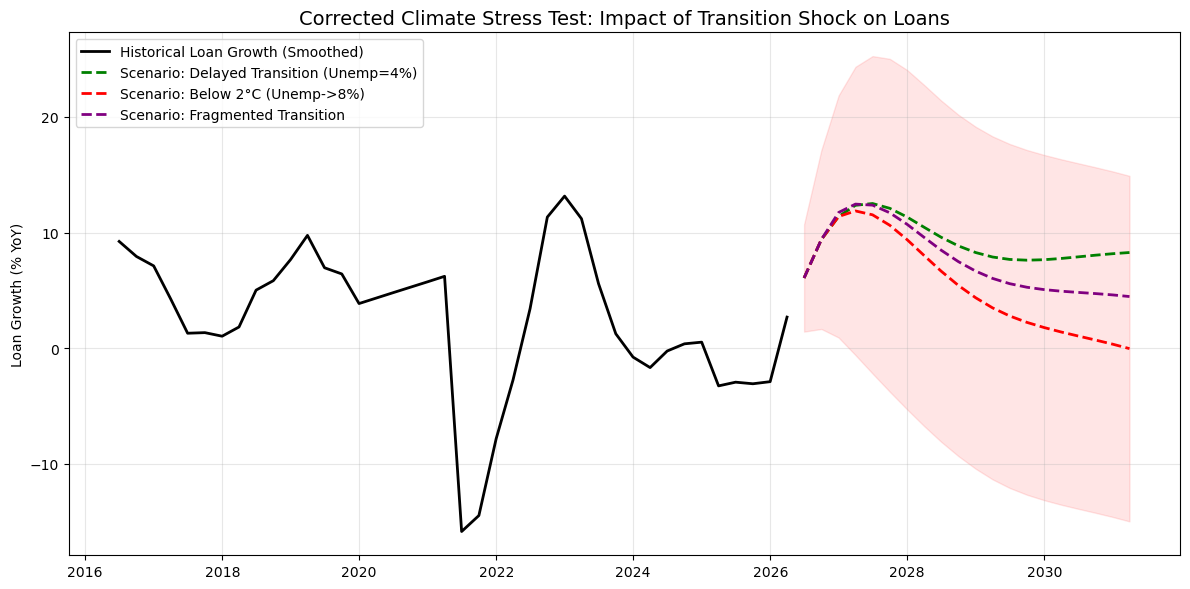

✅ Analysis Complete.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. ROBUST DATA CLEANING (Standardized)
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        # Find date column
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        
        # Force numeric and resample to Quarter End
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        df_q = df.resample('QE').mean()
        
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        print(f"⚠️ Error cleaning {file_path}: {e}")
        return pd.DataFrame()

# 2. LOAD & PREPARE DATA

df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

# Merge
df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()

# Create Initial Target: Loan Growth (Log Difference)
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100

# 3. WINSORIZE (SMOOTH) THE 2020 SHOCK to prevent the model from learning "broken" economics from the pandemic.
# We smooth BOTH the Target (Loans) and the Input (Unemployment)
print("Smoothing 2020 Volatility...")

shock_start = '2020-03-01'
shock_end = '2020-12-31'

# A. Smooth Loans
df_history.loc[shock_start:shock_end, 'Loan_Growth'] = np.nan
df_history['Loan_Growth'] = df_history['Loan_Growth'].interpolate(method='linear')

# B. Smooth Unemployment (CRITICAL fix for logic)
df_history.loc[shock_start:shock_end, 'Unemployment_Rate'] = np.nan
df_history['Unemployment_Rate'] = df_history['Unemployment_Rate'].interpolate(method='linear')

# ---------------------------------------------------------
# 4. FEATURE ENGINEERING (Post-Smoothing)
# ---------------------------------------------------------
# We calculate lags *after* smoothing so the shock doesn't "leak" into the lag
df_history['Unemployment_Lag2'] = df_history['Unemployment_Rate'].shift(2)

# Drop NaNs created by shifting/differencing
df_train = df_history.dropna()

print(f"✅ Data Prepared & Smoothed. Training Rows: {len(df_train)}")

# 5. TRAIN MODEL (Optimized SARIMA)
# Y = Loan Growth
# X = Unemployment (Lagged)
y = df_train['Loan_Growth']
X = df_train[['Unemployment_Lag2']] 

print("\nTraining ARIMA")
model = ARIMA(y, exog=X, order=(2, 0, 2)) 
model_fit = model.fit()

print(model_fit.summary())

# ---------------------------------------------------------
# 6. PREPARE SCENARIOS
# ---------------------------------------------------------
steps = 20 # 5 Years
future_dates = pd.date_range(start=df_train.index[-1], periods=steps+1, freq='QE')[1:]

# --- Scenario A: Delayed Transition (Low Stress) ---
# Unemployment stays flat/low (4.0%)
future_delayed = pd.DataFrame(index=future_dates)
future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                    df_history['Unemployment_Rate'].iloc[-1], 
                                                    steps)
future_delayed['Loans_Billions'] = 0 # Placeholder
future_delayed['CPI'] = 0 # Placeholder

# Combine with history to calculate lags correctly
df_total_delayed = pd.concat([df_history, future_delayed])
df_total_delayed['Unemployment_Lag2'] = df_total_delayed['Unemployment_Rate'].shift(2)
# Slice back to just the future part
X_future_delayed = df_total_delayed.iloc[-steps:][['Unemployment_Lag2']]


# --- Scenario B: Below 2°C (High Stress) ---
# Unemployment spikes to 8% due to transition shock
future_stress = pd.DataFrame(index=future_dates)
future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                    df_history['Unemployment_Rate'].iloc[-1]+8, 
                                                    steps)
future_stress['Loans_Billions'] = 0
future_stress['CPI'] = 0

# Combine & Lag
df_total_stress = pd.concat([df_history, future_stress])
df_total_stress['Unemployment_Lag2'] = df_total_stress['Unemployment_Rate'].shift(2)
# Slice
X_future_stress = df_total_stress.iloc[-steps:][['Unemployment_Lag2']]

# Scenario C: fragmented 
future_fragmented = pd.DataFrame(index=future_dates)
future_fragmented['Unemployment_Rate'] = np.linspace(4.0, 8.0, steps)
future_fragmented['Physical_Risk_Dummy'] = 0
future_fragmented.loc[future_fragmented.index >= future_fragmented.index[12], 'Physical_Risk_Dummy'] = 1
future_fragmented['Loans_Billions'] = 0
future_fragmented['CPI'] = 0
# Combine & Lag
df_total_fragmented = pd.concat([df_history, future_fragmented])
df_total_fragmented['Unemployment_Lag2'] = df_total_fragmented['Unemployment_Rate'].shift(2)
# slice 
X_future_fragmented = df_total_fragmented.iloc[-steps:]['Unemployment_Lag2']

# ---------------------------------------------------------
# 7. RUN FORECASTS
# ---------------------------------------------------------
print("\nRunning Forecasts...")

# Forecast A (Delayed)
forecast_delayed = model_fit.get_forecast(steps=steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

# Forecast B (Stress)
forecast_stress = model_fit.get_forecast(steps=steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int = forecast_stress.conf_int(alpha=0.05) # 95% Confidence Interval
# Forecast C (fragmented)
forecast_fragmented = model_fit.get_forecast(steps=steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
# ---------------------------------------------------------
# 8. VISUALIZE RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot History (Last 10 Years)
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)

# Plot Delayed (Green)
plt.plot(pred_delayed.index, pred_delayed, 
         label='Scenario: Delayed Transition (Unemp=4%)', color='green', linestyle='--', linewidth=2)

# Plot Stress (Red)
plt.plot(pred_stress.index, pred_stress, 
         label='Scenario: Below 2°C (Unemp->8%)', color='red', linestyle='--', linewidth=2)
# Plot Fragmented (Purple)
plt.plot(pred_fragmented.index, pred_fragmented, 
         label='Scenario: Fragmented Transition', color='purple', linestyle='--', linewidth=2)
# Confidence Interval (Red Shading)
plt.fill_between(pred_stress.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1)

plt.title('Corrected Climate Stress Test: Impact of Transition Shock on Loans', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Analysis Complete.")

## integrate the NGFS data into our models

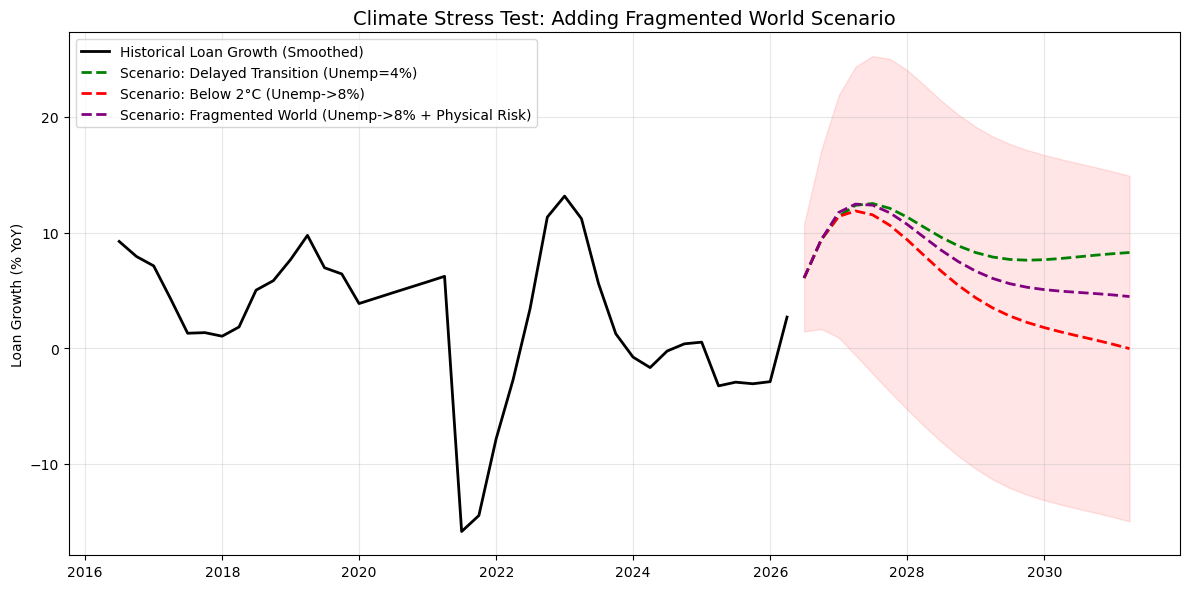

In [28]:
## recreate model with other scenarios such as Fragmented World with high transition and high physical risk
## assume delayed reaction to transition shock with high physical risk in the future
# --- Scenario C: Fragmented World (High Transition + High Physical Risk) ---

future_fragmented = pd.DataFrame(index=future_dates)
# Transition Shock: Unemployment spikes to 8% (same as stress scenario)
future_fragmented['Unemployment_Rate'] = np.linspace(4.0, 8.0, steps)
# Physical Risk: We can simulate this by adding a dummy variable that turns "on" after 3 years
future_fragmented['Physical_Risk_Dummy'] = 0
future_fragmented.loc[future_fragmented.index >= future_fragmented.index[12], 'Physical_Risk_Dummy'] = 1
future_fragmented['Loans_Billions'] = 0
future_fragmented['CPI'] = 0
# Combine & Lag
df_total_fragmented = pd.concat([df_history, future_fragmented])
df_total_fragmented['Unemployment_Lag2'] = df_total_fragmented['Unemployment_Rate'].shift(2)
# Slice
X_future_fragmented = df_total_fragmented.iloc[-steps:]['Unemployment_Lag2']
# Forecast Fragmented
forecast_fragmented = model_fit.get_forecast(steps=steps, exog=X_future_fragmented)
pred_fragmented = forecast_fragmented.predicted_mean
# Plot Fragmented (Purple)
plt.figure(figsize=(12, 6))
plt.plot(df_train.index[-40:], df_train['Loan_Growth'][-40:], 
         label='Historical Loan Growth (Smoothed)', color='black', linewidth=2)
plt.plot(pred_delayed.index, pred_delayed,
            label='Scenario: Delayed Transition (Unemp=4%)', color='green', linestyle='--', linewidth=2)
plt.plot(pred_stress.index, pred_stress,
            label='Scenario: Below 2°C (Unemp->8%)', color='red', linestyle='--', linewidth=2)
plt.plot(pred_fragmented.index, pred_fragmented,
            label='Scenario: Fragmented World (Unemp->8% + Physical Risk)', color='purple', linestyle='--', linewidth=2)
plt.fill_between(pred_stress.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.1)
plt.title('Climate Stress Test: Adding Fragmented World Scenario', fontsize=14)
plt.ylabel('Loan Growth (% YoY)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
## model validation using backtesting on historical data
# Backtesting with Walk-Forward Validation  
from sklearn.metrics import mean_absolute_error
# We will use the last 5 years for backtesting
backtest_start = df_train.index[-20]  # Last 5 years (20 quarters)
# Store predictions and actuals
backtest_predictions = []
backtest_actuals = []
# Walk-forward loop
for i in range(20, len(df_train)):
    # Train on data up to the current point
    train_data = df_train.iloc[:i]
    y_train = train_data['Loan_Growth']
    X_train = train_data[['Unemployment_Lag2']]
    
    # Fit model
    model_bt = ARIMA(y_train, exog=X_train, order=(2, 0, 2))
    model_fit_bt = model_bt.fit()
    
    # Predict the next quarter
    X_next = df_train.iloc[i][['Unemployment_Lag2']].values.reshape(1, -1)
    pred_next = model_fit_bt.get_forecast(steps=1, exog=X_next).predicted_mean[0]
    
    # Store prediction and actual
    backtest_predictions.append(pred_next)
    backtest_actuals.append(df_train['Loan_Growth'].iloc[i])
# Calculate MAE
mae = mean_absolute_error(backtest_actuals, backtest_predictions)
print(f"Backtesting MAE: {mae:.4f}")
# calculat relative error
relative_errors = np.abs(np.array(backtest_predictions) - np.array(backtest_actuals)) / np.abs(backtest_actuals)
average_relative_error = np.mean(relative_errors)
print(f"Average Relative Error: {average_relative_error:.4f}")

Backtesting MAE: 1.5124
Average Relative Error: 0.3854


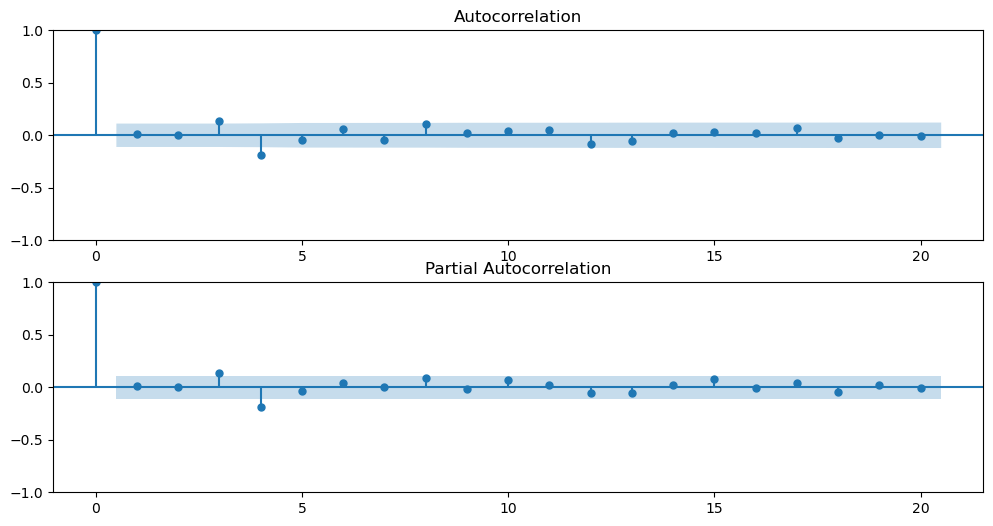

In [20]:
## pull out autocorrelation and partial autocorrelation plots to check for remaining patterns in the residuals
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = model_fit.resid
plt.figure(figsize=(12, 6))
plt.subplot(211)
plot_acf(residuals, ax=plt.gca(), lags=20)
plt.subplot(212)
plot_pacf(residuals, ax=plt.gca(), lags=20)
plt.show()

In [21]:
physicaldata = pd.read_excel('/Users/geoffpoint-du-jour/Downloads/Forecasting/ECON-522-Forecasting-Project/Climate Data/Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx')

In [22]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [30]:
# ---------------------------------------------------------
# 6. LOAD & PROCESS NGFS (WIDE FORMAT CONVERSION)
# ---------------------------------------------------------
print("\nProcessing NGFS Scenarios (Wide Format)...")

# ==============================================================================
# A. CONFIGURATION (Updated for NiGEM/NGFS Structure)
# ==============================================================================
# Point to your NiGEM or Downscaled NGFS CSV
file_path = 'NiGEM_data.xlsx'

# Typical NGFS strings - update these if your specific file uses different ones
TARGET_REGION = 'United States' 

# Variables often appear as 'Unemployment Rate' or 'Price|Consumer Price Index'
VAR_UNEMP = 'Unemployment Rate' 
VAR_INFL  = 'Inflation Rate'    

# Scenarios often include a prefix like 'NGFS Phase 4' or 'Disorderly'
SCENARIO_DELAYED = 'Delayed transition'
SCENARIO_NETZERO = 'Net Zero 2050'
# ==============================================================================

try:
    # 1. Load Raw Data with Latin-1 encoding to fix UnicodeDecodeError
    df_raw = pd.read_csv(file_path, encoding='latin-1')
    print(f"✅ Loaded {file_path}. Rows: {len(df_raw)}")
    
    # Strip whitespace from string columns to prevent matching errors
    string_cols = ['Region', 'Variable', 'Scenario']
    for col in string_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].astype(str).str.strip()

    # 2. Filter for Region
    df_reg = df_raw[df_raw['Region'] == TARGET_REGION].copy()
    if df_reg.empty:
        print(f"❌ ERROR: No data found for Region '{TARGET_REGION}'.")
        print("Available Regions:", df_raw['Region'].unique()[:5])
        raise ValueError("Region Not Found")

    # 3. Flexible Extract Function
    def extract_scenario_series(df, scenario_name, var_name):
        # We use str.contains in case there are prefixes like 'Phase 4 | Delayed transition'
        mask = (df['Scenario'].str.contains(scenario_name, case=False, na=False)) & \
               (df['Variable'].str.contains(var_name, case=False, na=False))
        row = df[mask]
        
        if row.empty:
            return None
        
        # Identify year columns (e.g., '2022', '2023'...)
        year_cols = [c for c in df.columns if c.isdigit()]
        ts_data = row[year_cols].T
        ts_data.columns = ['Value']
        ts_data.index.name = 'Year'
        return pd.to_numeric(ts_data['Value'], errors='coerce')

    # 4. Extract Data
    s_unemp_delayed = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_UNEMP)
    s_infl_delayed  = extract_scenario_series(df_reg, SCENARIO_DELAYED, VAR_INFL)
    s_unemp_netzero = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_UNEMP)
    s_infl_netzero  = extract_scenario_series(df_reg, SCENARIO_NETZERO, VAR_INFL)

    # 5. Build cleaned Scenario DataFrame
    df_ngfs_clean = pd.DataFrame({
        'Unemp_Delayed': s_unemp_delayed,
        'Infl_Delayed': s_infl_delayed,
        'Unemp_NetZero': s_unemp_netzero,
        'Infl_NetZero': s_infl_netzero
    }).dropna()

    if df_ngfs_clean.empty:
        raise ValueError("Could not find matching Scenarios/Variables. Check debug info below.")

    # 6. Convert Index to Datetime & Resample to Quarterly
    df_ngfs_clean.index = pd.to_datetime(df_ngfs_clean.index.astype(str) + '-12-31')
    
    # Quarterly interpolation
    future_dates = pd.date_range(start=df_train.index[-1], periods=21, freq='QE')[1:]
    df_ngfs_q = df_ngfs_clean.resample('QE').asfreq().interpolate(method='linear')
    df_ngfs_future = df_ngfs_q.reindex(future_dates).fillna(method='ffill')
    
    print("✅ NGFS Data successfully prepared.")
    print(df_ngfs_future.head())

except Exception as e:
    print(f"❌ Error: {e}")
    if 'df_raw' in locals():
        print("\n--- DEBUG INFO ---")
        print("Variables in CSV:", df_raw['Variable'].unique()[:10])
        print("Scenarios in CSV:", df_raw['Scenario'].unique()[:5])


Processing NGFS Scenarios (Wide Format)...
❌ Error: Error tokenizing data. C error: Expected 2 fields in line 7, saw 4



In [24]:
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                    df_history['Unemployment_Rate'].iloc[-1]+0.5,
                                                    steps)

# Stress Scenario: Below 2°C Transition Shock (high stress)
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                   df_history['Unemployment_Rate'].iloc[-1]+4.0,
                                                   steps)

In [25]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       